# Chinese world — share of notable individuals per polity, over time

Counterpart to **Laouenan et al. 2022, Figure S8 (left panel)**: stacked-area flow of the share of living notable individuals over time, broken down — instead of by *citizenship country* — by **canonical Chinese polities** (dynasties), using only polity names / dates that exist in `polities_cliopatria`.

Each individual contributes uniformly across their `floruit_period` interval (weight `1/width`). Years are rounded to the nearest 50-year mark; an incomplete trailing bucket is dropped (project convention).

## 1. Configuration

In [1]:
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../data/humans_clean.duckdb'

# 50-year buckets (project convention).
BUCKET = 50

# Chronologically warm→cool palette, one colour per main polity.
PALETTE = {
    'Shang':          '#6c2a2c',
    'Zhou':           '#8e4f33',
    'Qin':            '#b07a3f',
    'Han':            '#c8a472',
    'Six Dynasties':  '#8e7a8a',
    'Sui':            '#6c8a8a',
    'Tang':           '#4f8a98',
    'Five Dynasties': '#5b6f8e',
    'Song':           '#3e5b8e',
    'Yuan':           '#6a4f8a',
    'Ming':           '#8e4f7a',
    'Qing':           '#a05a6a',
}

import matplotlib as _mpl
_mpl.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 12,
    'font.family': 'DejaVu Sans',
})

In [2]:
import duckdb
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

## 2. Canonical Chinese polity list and grouping into main polities

Same canonical sequence used in `notebooks/13b_chinese_dynasties_floruit.ipynb` and `notebooks/21_chinese_world_yearly_ci.ipynb`. Eastern Jin is absent from the database, so we only use polities that are actually present.

For visual readability the 23 polities are mapped to **12 main polities** (textbook periodisation). Every label below is either a polity name from `polities_cliopatria` (treated as its own group) or the textbook name of a *period* whose constituent polities are listed explicitly — no dates are invented; the X-axis comes from `polities_periods_cliopatria`.

In [3]:
POLITY_TO_MAIN = {
    'Shang Dynasty':                   'Shang',
    'Zhou Dynasty':                    'Zhou',
    'Qin Dynasty':                     'Qin',
    'Han Dynasty':                     'Han',
    'Xin Dynasty':                     'Han',
    'Western Jin':                     'Six Dynasties',
    'Liu Song Dynasty':                'Six Dynasties',
    'Liang Dynasty':                   'Six Dynasties',
    'Chen Dynasty':                    'Six Dynasties',
    'Northern Wei':                    'Six Dynasties',
    'Eastern Wei':                     'Six Dynasties',
    'Western Wei':                     'Six Dynasties',
    'Northern Zhou':                   'Six Dynasties',
    'Northern Qi':                     'Six Dynasties',
    'Sui Dynasty':                     'Sui',
    'Tang Dynasty':                    'Tang',
    'Five Dynasties and Ten Kingdoms': 'Five Dynasties',
    'Liao Dynasty':                    'Five Dynasties',
    'Western Xia':                     'Five Dynasties',
    'Northern Song':                   'Song',
    'Southern Song':                   'Song',
    'Yuan Dynasty':                    'Yuan',
    'Ming Dynasty':                    'Ming',
    'Qing Dynasty':                    'Qing',
}

# Plot order is also the chronological order of the main polities.
MAIN_ORDER = ['Shang', 'Zhou', 'Qin', 'Han', 'Six Dynasties', 'Sui',
              'Tang', 'Five Dynasties', 'Song', 'Yuan', 'Ming', 'Qing']

len(POLITY_TO_MAIN), len(MAIN_ORDER)

(24, 12)

## 3. Polity hulls (from the database)

Used only to anchor the X-axis and to set the year window. The hull of each canonical polity is the `(MIN(from_year), MAX(to_year))` of its rows in `polities_periods_cliopatria`.

In [4]:
polities = list(POLITY_TO_MAIN)
ph = ','.join(['?'] * len(polities))

conn = duckdb.connect(DB_PATH, read_only=True)
periods = conn.execute(f"""
    SELECT pc.name AS polity,
           MIN(pp.from_year) AS from_year,
           MAX(pp.to_year)   AS to_year
    FROM polities_cliopatria pc
    JOIN polities_periods_cliopatria pp ON pc.id = pp.polity_id
    WHERE pc.name IN ({ph})
    GROUP BY pc.name
""", polities).pl()
conn.close()

# Hull of each *main* polity = hull-of-hulls of its constituent polities.
main_periods = (
    periods.with_columns(
        pl.col('polity').replace_strict(POLITY_TO_MAIN).alias('main')
    )
    .group_by('main')
    .agg([pl.col('from_year').min().alias('from_year'),
          pl.col('to_year').max().alias('to_year')])
    .with_columns(
        pl.col('main').replace_strict({n: i for i, n in enumerate(MAIN_ORDER)}).alias('_o')
    )
    .sort('_o')
    .drop('_o')
)
main_periods

main,from_year,to_year
str,i64,i64
"""Shang""",-1600,-1001
"""Zhou""",-1000,-751
"""Qin""",-218,-209
"""Han""",-202,237
"""Six Dynasties""",265,591
…,…,…
"""Five Dynasties""",911,1226
"""Song""",961,1278
"""Yuan""",1294,1374


## 4. Load Chinese-world individuals with a floruit interval

Each row already carries one canonical polity (`polity_name`) and a `floruit_period_start` / `floruit_period_end` interval. The floruit interval IS the impact period in this database: by construction it spans roughly age 30→55 from the birth year (see `notebooks/28_fig_floruit_period_methods.ipynb`). For each individual `i` with width `w_i = e_i - s_i + 1` we treat the year of activity as uniform on `[s_i, e_i]`; the contribution to a year `y` is `1/w_i` if `s_i ≤ y ≤ e_i`.

In [5]:
conn = duckdb.connect(DB_PATH, read_only=True)
df = conn.execute(f"""
    SELECT DISTINCT ic.wikidata_id,
           ic.polity_name AS polity,
           fp.floruit_period_start AS s,
           fp.floruit_period_end   AS e
    FROM individuals_cliopatria ic
    JOIN individuals_floruit_period fp USING (wikidata_id)
    WHERE ic.polity_name IN ({ph})
      AND fp.floruit_period_start IS NOT NULL
      AND fp.floruit_period_end   IS NOT NULL
""", polities).pl()
conn.close()

df = (
    df.with_columns(
        pl.col('s').cast(pl.Int64),
        pl.col('e').cast(pl.Int64),
        pl.col('polity').replace_strict(POLITY_TO_MAIN).alias('main'),
    )
    .with_columns((pl.col('e') - pl.col('s') + 1).alias('w'))
    .filter(pl.col('w') >= 1)
)

assert df['main'].is_in(MAIN_ORDER).all(), 'unexpected main-polity label'
assert df.select(pl.col('wikidata_id').is_unique().all()).item(), 'individuals not unique'

print(f'{df.height:,} unique Chinese-world individuals with a floruit interval')
df.group_by('main').agg(pl.len().alias('n')).sort('n', descending=True)

85,880 unique Chinese-world individuals with a floruit interval


main,n
str,u32
"""Qing""",31094
"""Tang""",25037
"""Ming""",16715
"""Song""",6859
"""Yuan""",2407
…,…
"""Sui""",1088
"""Five Dynasties""",184
"""Qin""",26


## 5. Per-year expected count, by main polity

Vectorised accumulation on a dense year axis using `np.add.at` on the `(start, end+1)` deltas, then `cumsum`. Each individual contributes `1/w_i` to every year inside their floruit interval.

In [6]:
YEAR_MIN = int(main_periods['from_year'].min())
YEAR_MAX = int(main_periods['to_year'].max())
years = np.arange(YEAR_MIN, YEAR_MAX + 1)
n_years = len(years)

# Clip floruit intervals to the display window.
df_clip = (
    df.filter((pl.col('e') >= YEAR_MIN) & (pl.col('s') <= YEAR_MAX))
      .with_columns(
          pl.col('s').clip(lower_bound=YEAR_MIN),
          pl.col('e').clip(upper_bound=YEAR_MAX),
      )
)

def expected_per_year(rows):
    s = rows['s'].to_numpy()
    e = rows['e'].to_numpy()
    w = rows['w'].to_numpy()
    p = 1.0 / w
    delta = np.zeros(n_years + 1)
    np.add.at(delta, s - YEAR_MIN,     p)
    np.add.at(delta, e - YEAR_MIN + 1, -p)
    return np.cumsum(delta)[:n_years]

yearly = {m: expected_per_year(df_clip.filter(pl.col('main') == m))
          for m in MAIN_ORDER}

yearly_df = pl.DataFrame({'year': years} | yearly)
yearly_df.head()

year,Shang,Zhou,Qin,Han,Six Dynasties,Sui,Tang,Five Dynasties,Song,Yuan,Ming,Qing
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-1600,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-1599,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-1598,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-1597,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-1596,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. 50-year buckets and shares

Project convention: round to the nearest 50-year mark; drop an incomplete trailing bucket. We bucket by the bucket *start* year `y // 50 * 50` so each bucket covers `[start, start + 50)`. The last partial bucket — the one whose right edge would extend beyond `YEAR_MAX` — is dropped.

In [7]:
import math

bucketed = (
    yearly_df.with_columns(
        ((pl.col('year') // BUCKET) * BUCKET).alias('bucket')
    )
    .group_by('bucket')
    .agg([pl.col(m).mean().alias(m) for m in MAIN_ORDER])
    .sort('bucket')
)

# Drop the trailing bucket if it is not complete (right edge > YEAR_MAX + 1).
last_full_bucket = (math.floor((YEAR_MAX + 1) / BUCKET) - 1) * BUCKET
if (YEAR_MAX + 1) % BUCKET == 0:
    last_full_bucket += BUCKET  # rare exact-fit case
bucketed = bucketed.filter(pl.col('bucket') <= last_full_bucket)

# Shares per bucket: each row sums to 1 (or 0 if no Chinese individual is active).
vals = bucketed.select(MAIN_ORDER).to_numpy()
totals = vals.sum(axis=1)
shares = np.where(totals[:, None] > 0, vals / np.where(totals > 0, totals, 1)[:, None], 0)

bucket_centers = bucketed['bucket'].to_numpy() + BUCKET / 2
print(f'buckets: {bucketed.height} (right edge = {last_full_bucket + BUCKET})')
print(f'totals (head): {totals[:5].round(1)} ...')

buckets: 70 (right edge = 1900)
totals (head): [0. 0. 0. 0. 0.] ...


## 7. Figure — share of Chinese-world notable individuals per main polity

Stacked-area chart, 0 → 100 % per 50-year bucket. Reads like Laouenan Figure S8 (left): each colour is one main polity, area at year *y* is the share of that polity among all Chinese-world individuals active in the bucket containing *y*.

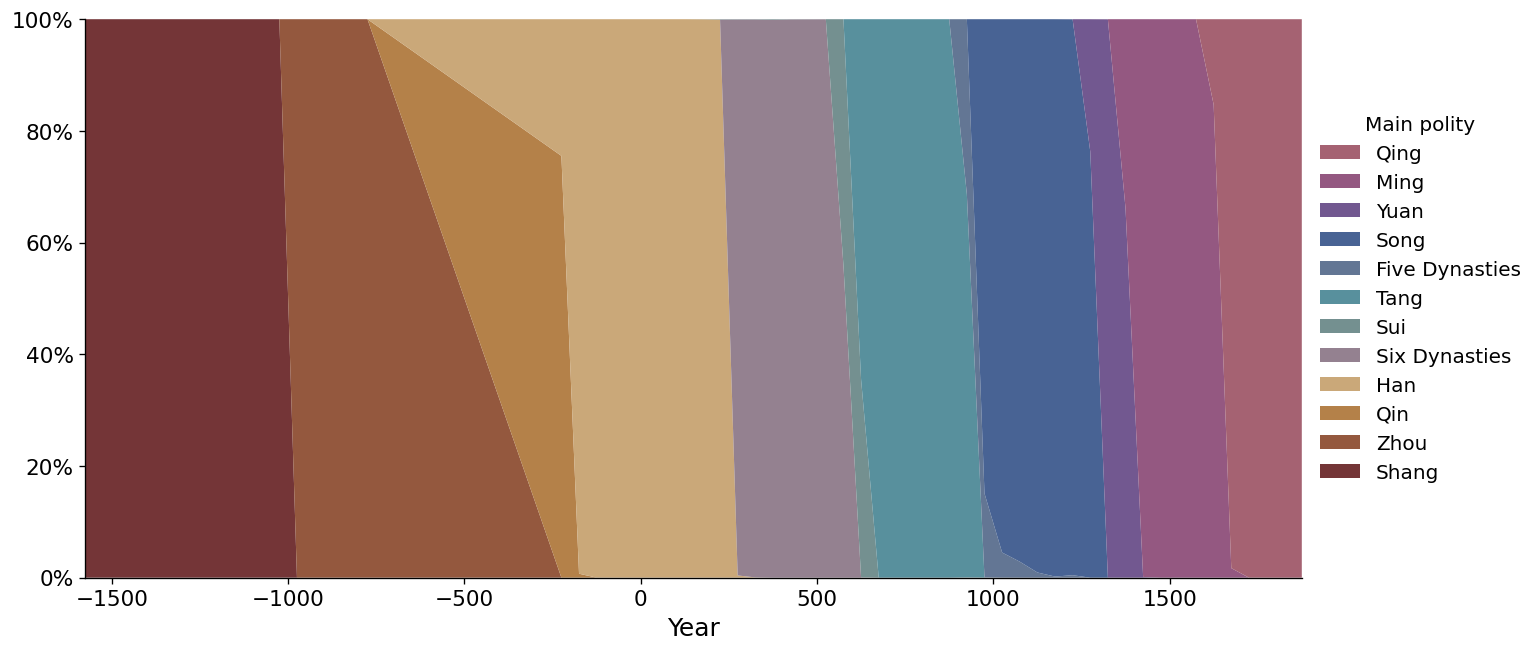

In [8]:
fig, ax = plt.subplots(figsize=(13, 5.6))

# Mask buckets where no Chinese individual is active so the area chart
# shows real coverage rather than spurious 0/0 = 0 fills.
active = totals > 0
x = bucket_centers[active]
y = shares[active].T  # shape (n_polities, n_buckets)

colors = [PALETTE[m] for m in MAIN_ORDER]
ax.stackplot(x, y, colors=colors, labels=MAIN_ORDER,
             alpha=0.95, linewidth=0)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlabel('Year', fontsize=15)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)

# Reverse legend order so the topmost polity in the stack appears first.
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], loc='center left', bbox_to_anchor=(1.0, 0.5),
          frameon=False, fontsize=12, title='Main polity', title_fontsize=12)

fig.tight_layout()
plt.show()

## 8. Companion — absolute counts (same decomposition, not normalised)

Useful sanity check: the absolute height shows how thinly the early millennia are covered (only a handful of Shang individuals) and how the database is dominated by the late imperial era.

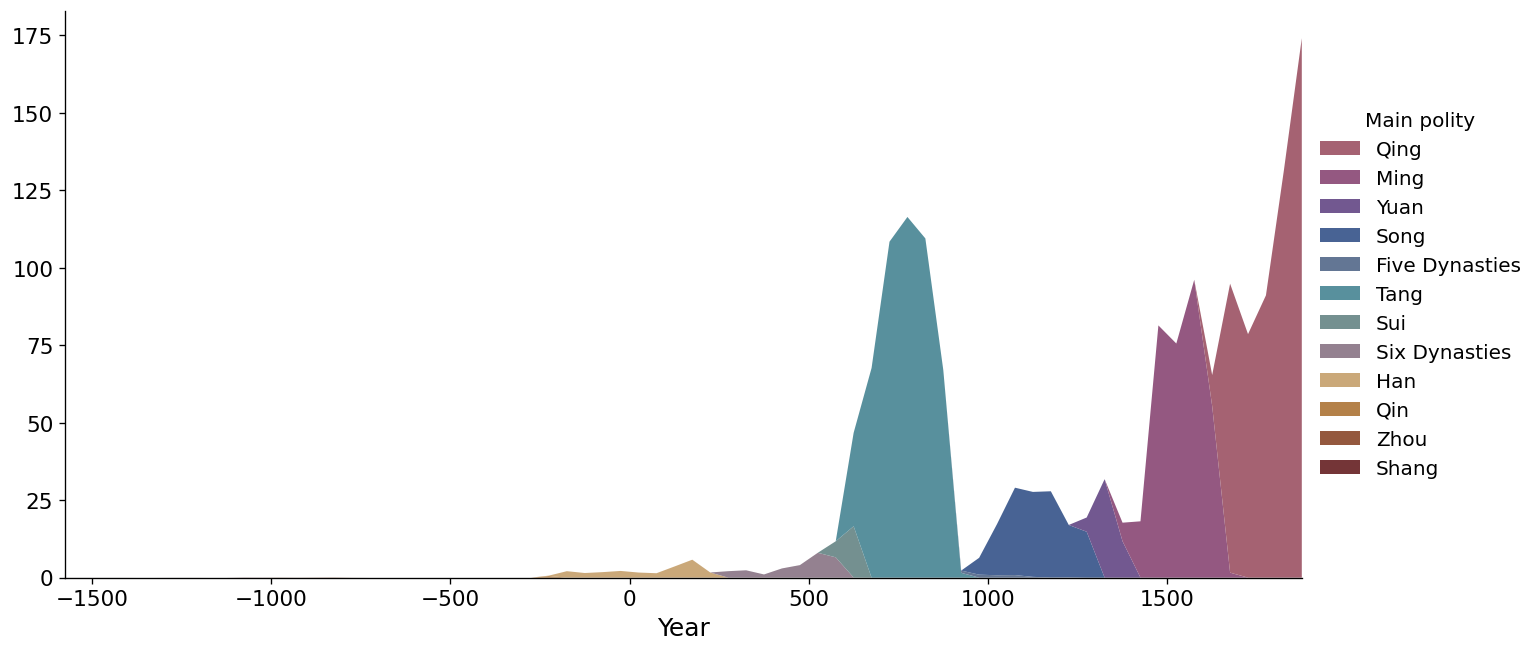

In [9]:
fig, ax = plt.subplots(figsize=(13, 5.6))

y_abs = bucketed.select(MAIN_ORDER).to_numpy().T  # shape (n_polities, n_buckets)
x_abs = bucket_centers

ax.stackplot(x_abs, y_abs, colors=colors, labels=MAIN_ORDER,
             alpha=0.95, linewidth=0)

ax.set_xlim(x_abs.min(), x_abs.max())
ax.set_ylim(0, None)
ax.set_xlabel('Year', fontsize=15)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.ticklabel_format(axis='y', style='plain')

h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], loc='center left', bbox_to_anchor=(1.0, 0.5),
          frameon=False, fontsize=12, title='Main polity', title_fontsize=12)

fig.tight_layout()
plt.show()

## 9. Summary table — per main polity

In [10]:
summary = (
    df.group_by('main').agg(pl.len().alias('individuals'))
    .join(main_periods, left_on='main', right_on='main')
    .with_columns(
        pl.col('main').replace_strict({n: i for i, n in enumerate(MAIN_ORDER)}).alias('_o')
    )
    .sort('_o')
    .drop('_o')
    .select(['main', 'from_year', 'to_year', 'individuals'])
)
summary

main,from_year,to_year,individuals
str,i64,i64,u32
"""Shang""",-1600,-1001,7
"""Zhou""",-1000,-751,11
"""Qin""",-218,-209,26
"""Han""",-202,237,1094
"""Six Dynasties""",265,591,1358
…,…,…,…
"""Five Dynasties""",911,1226,184
"""Song""",961,1278,6859
"""Yuan""",1294,1374,2407
